In [ ]:
# IF you are using Colab, uncomment:
#!pip install git+https://github.com/Alirezad126/SparseDPC.git@src

### 📦 Imports and Environment Setup


In [22]:
import torch.nn as nn
import os
import copy
import torch
import numpy as np
import wandb
from datetime import datetime
import matplotlib.pyplot as plt
import copy

# Neuromancer imports: modeling, loss, logging, system dynamics
from neuromancer.loggers import BasicLogger
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import ode, integrators
from neuromancer.plot import pltCL, pltPhase

# SparseDPC-specific modules: libraries, data, training, utils
from SparseDPC.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.data.getdata import get_data, get_policy_data
from SparseDPC.trainer.trainer import SparseTrainer
from SparseDPC.utils.integrator import OneElementEulerIntegrator, FullStateEulerIntegrator
from SparseDPC.utils.utils import map_to_new_fx, save_model_with_timestamp
from SparseDPC.utils.loggers import CustomLogger

# Set random seed for reproducibility
torch.manual_seed(0)

# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


## ⚙️ Training System ID with SINDy


### ⚙️ Define Ground Truth System and Problem Parameters



In [12]:
# Ground truth system model
gt_model = psl.nonautonomous.TwoTank()

# Sampling rate
ts = gt_model.params[1]['ts']

# Problem dimensions
nx = gt_model.nx      # number of states
nu = gt_model.nu      # number of control inputs
nref = nx             # reference dimensions equal to state dimensions

# Constraint bounds
umin = 0.
umax = 1.
xmin = 0.
xmax = 1


### 🧠 Generate Candidate Sparse Dynamics Models

This cell creates a list of candidate sparse dynamic models for each state dimension using `fx_library`, and prints them for inspection. Each model is configured with the same number of states, inputs, and device.


In [13]:
# Create one fx model per state dimension
fx_models = [fx_library(i, nx=nx, nu=nu, seed=0, device=device) for i in range(nx)]

# Print model structures
for fx in fx_models:
    print(fx)


dx0/dt = -0.004*x0 + 0.268*x1 + -0.412*x0^2 + -0.368*x0*x1 + -0.193*x1^2 + 0.134*u_0 + -0.010*u_1 + 0.396*u_0*u_1 + -0.044*x0*u_0 + 0.132*x1*u_0 + -0.151*x0*u_1 + -0.098*x1*u_1 + -0.478*sqrt(x0) + -0.331*sqrt(x1) 

dx1/dt = -0.004*x1 + 0.268*x0 + -0.412*x0^2 + -0.368*x0*x1 + -0.193*x1^2 + 0.134*u_0 + -0.010*u_1 + 0.396*u_0*u_1 + -0.044*x0*u_0 + 0.132*x1*u_0 + -0.151*x0*u_1 + -0.098*x1*u_1 + -0.478*sqrt(x0) + -0.331*sqrt(x1) 



### 📊 Get data

Gets training, dev, and test datasets using the ground truth model.


In [18]:
nsim = 2000   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 100     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

### 🔁 Train SINDy for System ID

Trains a sparse model for each state using one-step loss.
High `epochs` and `prune_every` allow convergence before pruning.
- `threshold`: sparsity cutoff for pruning small weights
- `threshold_mult`: increasing the threshold after prunning, as coefficient of the remaining terms will grow after prunning other unimportant terms


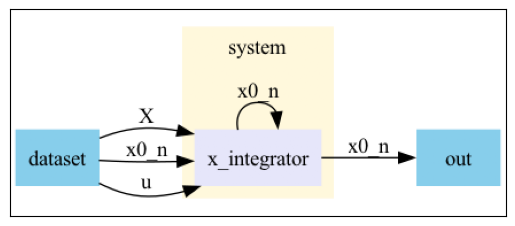

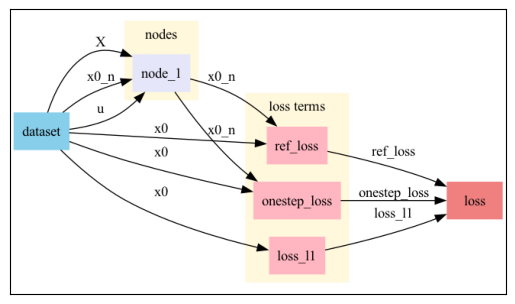

None
epoch: 0	train_loss: 0.00000	dev_loss: 0.00000	eltime:  0.70967
epoch: 500	train_loss: 0.00000	dev_loss: 0.00000	eltime:  11.99705

---------- Model 0 BEFORE pruning ----------
dx0/dt = -0.039*sqrt(x0) + 0.077*u_0 + -0.077*u_0*u_1 

   Threshold=0.002  Active=3  (prev=3)
   Pruned terms: []

⇒ No change in active sets; coefficients kept.

---------- Model 0 AFTER pruning  ----------
dx0/dt = -0.039*sqrt(x0) + 0.077*u_0 + -0.077*u_0*u_1 

epoch: 1000	train_loss: 0.00000	dev_loss: 0.00000	eltime:  23.18464
epoch: 1500	train_loss: 0.00000	dev_loss: 0.00000	eltime:  34.41220

---------- Model 0 BEFORE pruning ----------
dx0/dt = -0.039*sqrt(x0) + 0.077*u_0 + -0.077*u_0*u_1 

   Threshold=0.00214  Active=3  (prev=3)
   Pruned terms: []

⇒ No change in active sets; coefficients kept.

---------- Model 0 AFTER pruning  ----------
dx0/dt = -0.039*sqrt(x0) + 0.077*u_0 + -0.077*u_0*u_1 

epoch: 2000	train_loss: 0.00000	dev_loss: 0.00000	eltime:  45.89571
epoch: 2500	train_loss: 0.00000	dev_

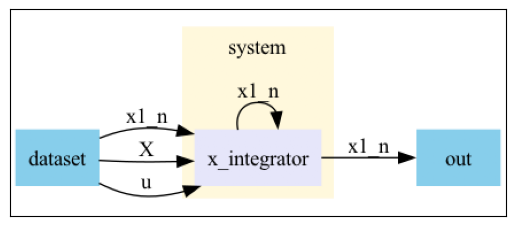

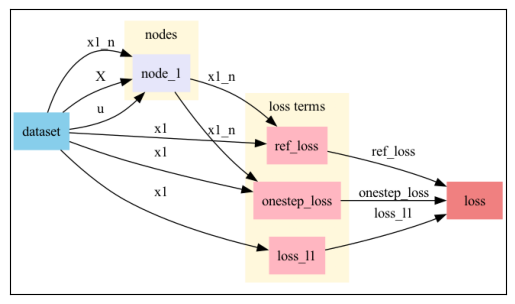

None
epoch: 0	train_loss: 0.00001	dev_loss: 0.00001	eltime:  0.71991
epoch: 500	train_loss: 0.00000	dev_loss: 0.00000	eltime:  7.82479

---------- Model 0 BEFORE pruning ----------
dx1/dt = 0.079*u_0*u_1 + 0.040*sqrt(x0) + -0.040*sqrt(x1) 

   Threshold=0.002  Active=3  (prev=3)
   Pruned terms: []

⇒ No change in active sets; coefficients kept.

---------- Model 0 AFTER pruning  ----------
dx1/dt = 0.079*u_0*u_1 + 0.040*sqrt(x0) + -0.040*sqrt(x1) 

epoch: 1000	train_loss: 0.00000	dev_loss: 0.00000	eltime:  15.13382
epoch: 1500	train_loss: 0.00000	dev_loss: 0.00000	eltime:  22.33713

---------- Model 0 BEFORE pruning ----------
dx1/dt = 0.079*u_0*u_1 + 0.040*sqrt(x0) + -0.040*sqrt(x1) 

   Threshold=0.00214  Active=3  (prev=3)
   Pruned terms: []

⇒ No change in active sets; coefficients kept.

---------- Model 0 AFTER pruning  ----------
dx1/dt = 0.079*u_0*u_1 + 0.040*sqrt(x0) + -0.040*sqrt(x1) 

epoch: 2000	train_loss: 0.00000	dev_loss: 0.00000	eltime:  29.79455
epoch: 2500	train_los

In [19]:
for i in range(nx):
    # One-element integrator for current state
    integrator_x = OneElementEulerIntegrator(fx_models[i], h=ts)
    integrator_node_x = Node(integrator_x, ['X', f'x{i}_n', 'u'], [f'x{i}_n'], name="x_integrator")
    dynamics_model_x = System([integrator_node_x])
    dynamics_model_x.show()

    x = variable(f"x{i}")
    x_hat = variable(f'x{i}_n')[:, :-1, :]

    # Define losses
    onestep_loss_x = 1.0 * ((x_hat[:, 1, :] == x[:, 1, :]) ^ 2)
    onestep_loss_x.name = "onestep_loss"

    reference_loss_x = 5.0 * ((x_hat == x) ^ 2)
    reference_loss_x.name = "ref_loss"

    # L1 sparsity regularization on model weights
    l1_x = variable([x], lambda x: torch.norm(list(fx_models[i].parameters())[0], p=1))
    loss_l1_x = 1e-6 * (l1_x == 0)
    loss_l1_x.name = "loss_l1"

    # Assemble problem
    objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
    loss_x = PenaltyLoss(objectives_x, [])
    problem_x = Problem([dynamics_model_x], loss_x)
    problem_x.show()

    optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=1e-3)

    logger = BasicLogger(
        args=None,
        savedir='test',
        verbosity=500,
        stdout=['dev_loss', 'train_loss']
    )

    trainer_x = SparseTrainer(
        problem=problem_x,
        fx_models=[fx_models[i]],
        lr=1e-3,
        train_data=None,
        test_data=None,
        optimizers=[optimizer_x],
        epochs=9999,
        train_metric='train_loss',
        eval_metric='dev_loss',
        logger=logger,
        device=device,
        threshold=0.002,
        prune_every=1000,
        warmup=300,
        patience=50,
        threshold_mult=1.07,
    )

    for _ in range(1):
        # Regenerate training data for updated horizon
        train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)
        trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
        trainer_x.problem = problem_x

        # Train
        best_model = trainer_x.train()
        trainer_x.model.load_state_dict(best_model)

        # Double prediction steps
        nsteps *= 2
        dynamics_model_x.nsteps = nsteps


In [16]:
# Final SINDy models for each state
for fx in fx_models:
    print(fx)

dx0/dt = -0.039*sqrt(x0) + 0.078*u_0 + -0.078*u_0*u_1 

dx1/dt = 0.079*u_0*u_1 + 0.040*sqrt(x0) + -0.040*sqrt(x1) 



### 📈 Evaluate SINDy Model

Simulates and plots predicted vs. true trajectories using the learned full-state model.


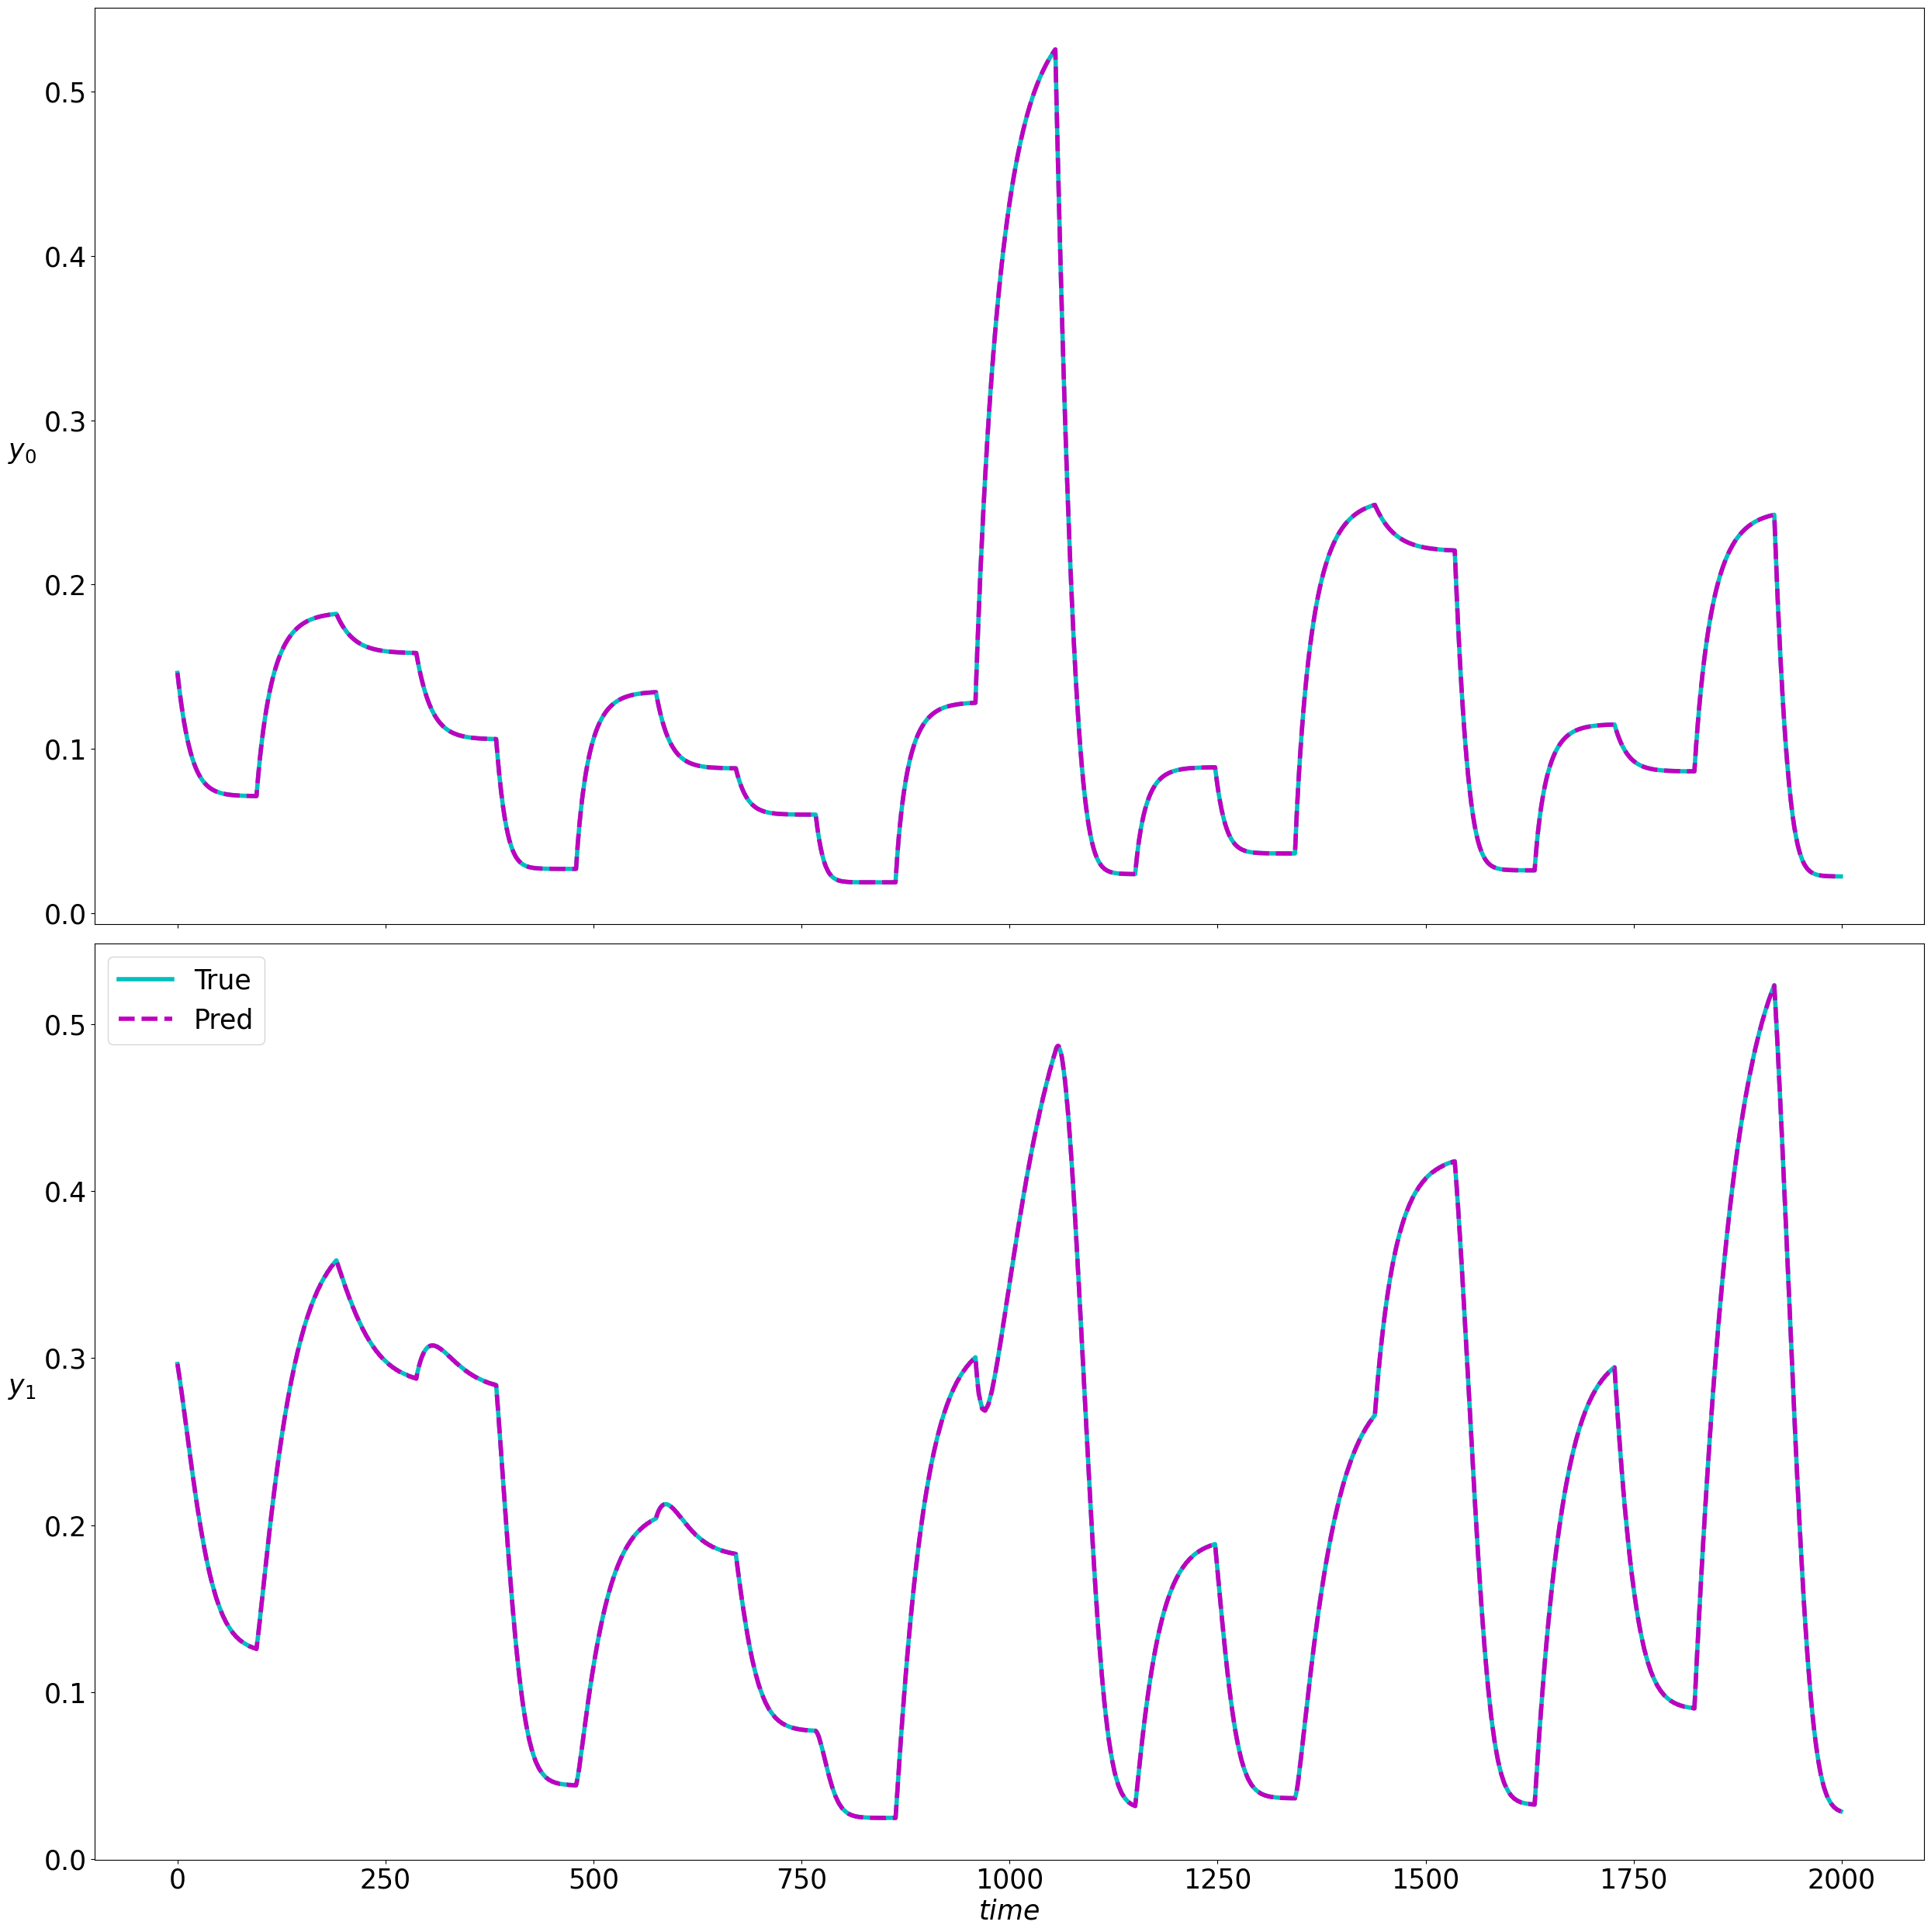

In [17]:
# Full-state integration using all fx_models
integrator_x = FullStateEulerIntegrator(fx_models, ts)
x_integrator_node = Node(integrator_x, ['xn', 'u'], ['xn'], name="x_integrator")

# Create system for evaluation
sindy_system = System([x_integrator_node], nsteps=nsteps)
sindy_system.nsteps = test_data['X'].shape[1]

# Run simulation
test_output = sindy_system(test_data)

# Reshape for plotting
pred_traj = test_output['xn'][:, :-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().numpy().reshape(-1, nx).T

# Plot predicted vs. true trajectories
figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]

for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    axe = ax[row] if nx > 1 else ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)

axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()


## ⚙️ Training the Sparse Dictionary Policy


###  Load Policy Data

Loads the trainig data for control problem


In [24]:
nsteps = 50  # prediction horizon
n_samples = 2500    # number of sampled scenarios
train_loader, dev_loader = get_policy_data(nsteps=nsteps,
                                           n_samples=n_samples,
                                           nx=nx,
                                           same_ref_for_all_states=True,
                                           device=device,
                                           batch_size=200,
                                           seed=5
                                           )
policies_seed = 5

###  Run Policy Training Grid

Trains and saves SINDy policies across multiple `l1_coef` and `threshold` configs with logging and pruning.


In [ ]:
import json

# === Setup ===
nsteps = 50
session_id = datetime.now().strftime("%Y%m%d_%H%M%S")
session_folder = f"results/session_{session_id}"
os.makedirs(session_folder, exist_ok=True)

# === Base Configuration ===
base_config = {
    'reg_coef': 100.0,
    'l1_coef': 1e-2,
    'const_coef': 10.0,
    'lr': 5e-3,
    'epochs': 3999,
    'threshold': 0.1,
    'prune_every': 250,
    'threshold_mult': 1.1,
}
l1_coef_list = [1e-2, 5e-3, 1e-3]
thresholds = [0.3, 0.2, 0.1, 0.05]

# === Run All Configurations ===
run_id = 0
for l1_coef in l1_coef_list:
    for threshold in thresholds:
        run_id += 1
        pol_configs = copy.deepcopy(base_config)
        pol_configs['threshold'] = threshold
        pol_configs['run_id'] = run_id

        run_name = f"TwoTank_run{run_id}_l1coef{l1_coef}_th{threshold}"
        save_dir = os.path.join(session_folder, run_name)
        os.makedirs(save_dir, exist_ok=True)

        wandb.init(
            project="sindy-TwoTank-multi-config",
            name=run_name,
            config=pol_configs,
            dir=save_dir,
            reinit=True,
        )

        # === Policy Setup ===
        policies = [
            fx_policy_library(nx=nx, nref=1, policy_name=f"u_{i}", seed=policies_seed, device=device)
            for i in range(nu)
        ]

        policy_node = Node(
            lambda xn, r: torch.cat([torch.clamp(fp(xn, r), umin, umax) for fp in policies], dim=-1),
            ['xn', 'r'], ['u'], name="policy_combined"
        )

        integrator_x = FullStateEulerIntegrator(fx_models, ts)
        x_integrator_node = Node(integrator_x, ['xn', 'u'], ['xn'], name="x_integrator")

        sindy_system = System([policy_node, x_integrator_node], nsteps=nsteps)

        x = variable('xn')
        ref = variable('r')

        regulation_loss = pol_configs['reg_coef'] * ((x == ref) ^ 2)
        regulation_loss.name = "state_loss"

        # L1 loss per policy
        loss_l1_policies = []
        for idx, fp in enumerate(policies):
            l1_raw = variable([x], lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1), display_name=f"l1_policy{idx}")
            l1_pen = l1_coef * (l1_raw == 0)
            l1_pen.name = f"loss_l1_policy_{idx}"
            loss_l1_policies.append(l1_pen)

        # State and terminal constraints
        c = pol_configs['const_coef']
        state_lower = c * (x > xmin); state_lower.name = "x_min"
        state_upper = c * (x < xmax); state_upper.name = "x_max"
        term_lower = c * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
        term_upper = c * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"

        objectives = [regulation_loss, *loss_l1_policies]
        constraints = [state_lower, state_upper, term_lower, term_upper]

        loss = PenaltyLoss(objectives, constraints)
        problem = Problem([sindy_system], loss)

        logger = CustomLogger(
            args=None,
            save_dir=save_dir,
            verbosity=10,
            stdout=['train_loss', 'dev_loss'],
            fx_policies=policies,
            pol_configs=pol_configs
        )

        trainer_policy = SparseTrainer(
            problem=problem,
            fx_models=policies,
            lr=pol_configs['lr'],
            train_data=train_loader,
            dev_data=dev_loader,
            optimizers=[torch.optim.AdamW(fp.parameters(), lr=pol_configs['lr']) for fp in policies],
            epochs=pol_configs['epochs'],
            train_metric='train_loss',
            eval_metric='dev_loss',
            logger=logger,
            device=device,
            threshold=pol_configs['threshold'],
            prune_every=pol_configs['prune_every'],
            threshold_mult=pol_configs['threshold_mult']
        )

        best_state = trainer_policy.train()

        # === Save final coefficients
        for i, fp in enumerate(policies):
            coef = fp.coef.detach().cpu().numpy()
            np.savetxt(f"{save_dir}/policy{i}_final.csv", coef, delimiter=",")
            wandb.log({f"final_active_terms_policy_{i}": int(np.count_nonzero(coef))})

        # === Save mapped models
        models_dir = os.path.join(save_dir, "saved_models")
        os.makedirs(models_dir, exist_ok=True)

        for i in range(nu):
            policy_name = f"u_{i}"
            policy_base = fx_policy_library(nx=nx, nref=1, policy_name=policy_name, seed=policies_seed, device=device)
            policy_mapped = map_to_new_fx(policies[i], policy_base)
            save_model_with_timestamp(policy_mapped, f"trained_policy_{i}", models_dir)

        # Save config
        with open(os.path.join(save_dir, "run_config.json"), "w") as f:
            json.dump(pol_configs, f, indent=4)

        wandb.finish()

# === Save session metadata ===
with open(os.path.join(session_folder, "session_config.txt"), "w") as f:
    f.write(f"Session ID: {session_id}\n")
    f.write(f"Started at: {datetime.now()}\n")
    f.write(f"Total runs: {run_id}\n")
    f.write(f"L1 Coef List: {l1_coef_list}\n")
    f.write(f"Thresholds: {thresholds}\n")


###  Train Combined Policy

Trains policy models jointly using a SINDy model with specific configuration


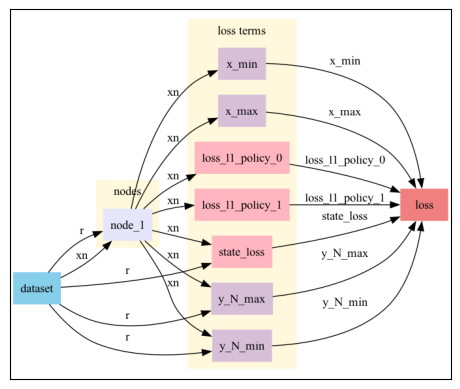

None
*** training with 50 steps ***
epoch: 0	train_loss: 5.20195	dev_loss: 6.32201	eltime:  1.87437
epoch: 100	train_loss: 3.48303	dev_loss: 4.33515	eltime:  206.96595


In [ ]:
pol_configs = {
    'reg_coef': 100.0,
    'l1_coef': 5e-3,
    'const_coef': 10.0,
    'lr': 1e-2,
    'epochs': 4999,
    'threshold': 0.2,
    'prune_every': 500,
    'threshold_mult': 1.1,
}

# Two policy components (e.g., for two control signals)
fx_policies = [
    fx_policy_library(nx=nx, nref=1, policy_name=f"u_{i}", seed=policies_seed, device=device)
            for i in range(nu)
        ]

# Combined control policy node
policy_node = Node(
    lambda xn, r: torch.cat(
        [torch.clamp(fp(xn, r), umin, umax) for fp in fx_policies],
        dim=-1),
    ['xn', 'r'], ['u'],
    name="policy_combined"
)

# System with policy + integrator
integrator_x = FullStateEulerIntegrator(fx_models, ts)
x_integrator_node = Node(integrator_x, ['xn', 'u'], ['xn'], name="x_integrator")
sindy_system = System([policy_node, x_integrator_node], nsteps=nsteps)

# Loss objectives
x = variable('xn')
ref = variable('r')
regulation_loss = pol_configs["reg_coef"] * ((x == ref) ^ 2)
regulation_loss.name = "state_loss"

# L1 sparsity penalties
loss_l1_policies = []
for idx, fp in enumerate(fx_policies):
    l1_raw = variable([x],
                      lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1),
                      display_name=f"l1_policy{idx}")
    l1_pen = pol_configs["l1_coef"] * (l1_raw == 0)
    l1_pen.name = f"loss_l1_policy_{idx}"
    loss_l1_policies.append(l1_pen)

# Constraints on state and terminal value
c = pol_configs["const_coef"]
state_lower = c * (x > xmin); state_lower.name = "x_min"
state_upper = c * (x < xmax); state_upper.name = "x_max"
term_lower  = c * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
term_upper  = c * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"

# Define optimization problem
objectives = [regulation_loss, *loss_l1_policies]
constraints = [state_lower, state_upper, term_lower, term_upper]
loss = PenaltyLoss(objectives, constraints)
problem = Problem([sindy_system], loss)
problem.show()

# Setup trainer
lr = pol_configs['lr']
optimizers = [torch.optim.AdamW(fp.parameters(), lr=lr) for fp in fx_policies]

trainer_policy = SparseTrainer(
    problem=problem,
    fx_models=fx_policies,
    lr=lr,
    train_data=train_loader,
    dev_data=dev_loader,
    optimizers=optimizers,
    epochs=pol_configs['epochs'],
    train_metric='train_loss',
    eval_metric='dev_loss',
    logger=BasicLogger(args=None, savedir='test', verbosity=100,
                       stdout=['dev_loss', 'train_loss']),
    device=device,
    threshold=pol_configs['threshold'],
    prune_every=pol_configs["prune_every"],
    threshold_mult=pol_configs["threshold_mult"]
)

print(f"*** training with {nsteps} steps ***")
best_state = trainer_policy.train()
trainer_policy.model.load_state_dict(best_state)

for i, fp in enumerate(fx_policies):
    print(f"Policy {i}:\n{fp}\n")


###  Closed-Loop Rollout (White-Box)

Simulates the learned policy in closed-loop using a ground-truth white-box ODE model.


In [ ]:
# White-box ODE model (ground truth)
two_tank = ode.TwoTankParam()
two_tank.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)

# Euler integrator for ODE system
gt_integrator = integrators.Euler(two_tank, h=torch.tensor(ts))
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

# Compose symbolic closed-loop system: policy + true plant
gt_sindy_policy = copy.deepcopy(System([policy_node, gt_integrator_node]))
gt_sindy_policy.show()

# Closed-loop simulation setup
nsteps = 1500
torch.manual_seed(63)
seed = 52
rng = np.random.default_rng(seed)

# Step reference signal (same across both states)
np_refs = psl.signals.step(nsteps+1, 1, min=xmin, max=xmax, randsteps=7, rng=rng)
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
torch_ref = torch.cat([R, R], dim=-1)

# Random initial state
x_sample = torch.rand(1, 1, nx, dtype=torch.float32)
data = {
    'xn': x_sample,
    'x0_n': x_sample[:, :, 0:1],
    'x1_n': x_sample[:, :, 1:2],
    'r': torch_ref
}

# Simulate system
gt_sindy_policy.nsteps = nsteps
trajectories = gt_sindy_policy(data)

# Constraint bounds for plotting
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])

# Plot trajectories
pltCL(
    Y=trajectories['xn'].detach().cpu().reshape(nsteps + 1, nx),
    R=trajectories['r'].detach().cpu().reshape(nsteps + 1, nref),
    U=trajectories['u'].detach().cpu().reshape(nsteps, nu),
    Umin=Umin, Umax=Umax,
    Ymin=Xmin, Ymax=Xmax
)
